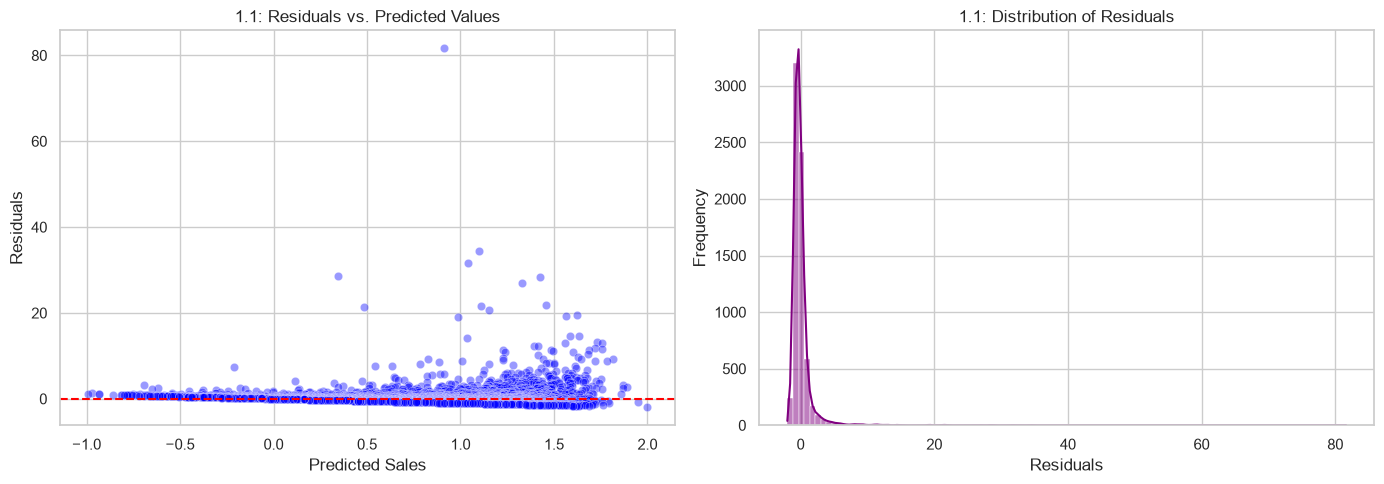

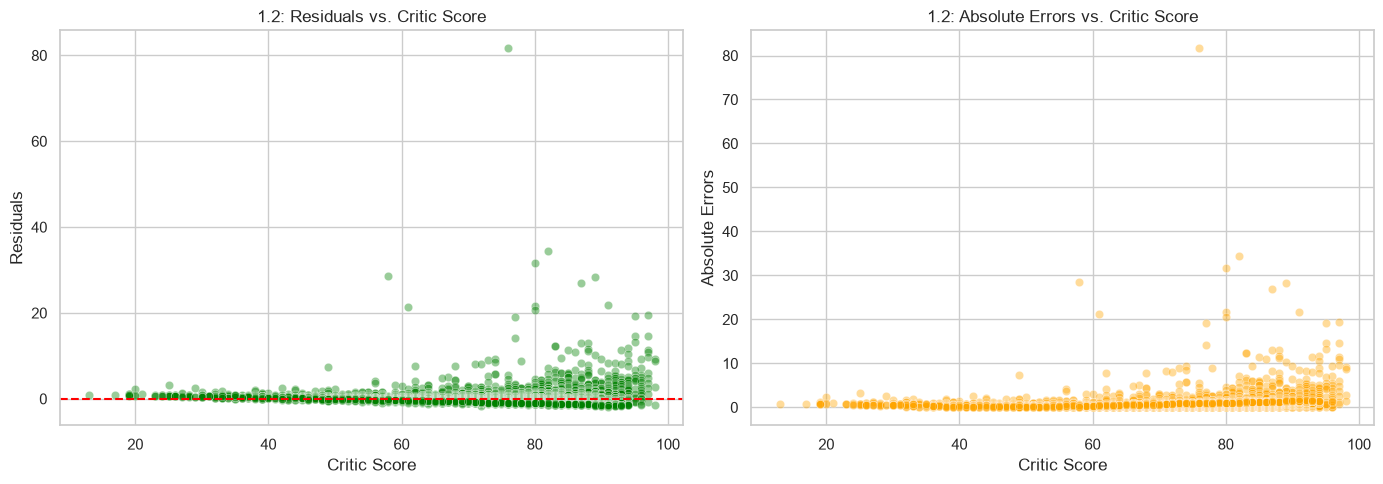

--- 1.3 Analysis of Extreme Errors ---
Threshold for top 5% absolute error: 1.74 Million
Top 5 Extreme Errors:
                    Name     Genre  Global_Sales  Predicted_Sales  Residuals  \
0             Wii Sports    Sports         82.53         0.913628  81.616372   
2         Mario Kart Wii    Racing         35.52         1.096650  34.423350   
3      Wii Sports Resort    Sports         32.77         1.038733  31.731267   
7               Wii Play      Misc         28.92         0.345905  28.574095   
6  New Super Mario Bros.  Platform         29.80         1.425215  28.374785   

   Abs_Errors  
0   81.616372  
2   34.423350  
3   31.731267  
7   28.574095  
6   28.374785  


--- 1.4 Statistical Properties of Errors ---
Mean Absolute Error (MAE): 0.7669
Standard Deviation of Residuals: 1.8968
Skewness: 17.1012
Kurtosis: 563.0467
--- 2. Regression Models Comparison (Including Bonus) ---

--- Linear Regression ---
MSE:  3.5973
RMSE: 1.8967
R^2:  0.0585

--- Decision Tree ---
MSE:  5

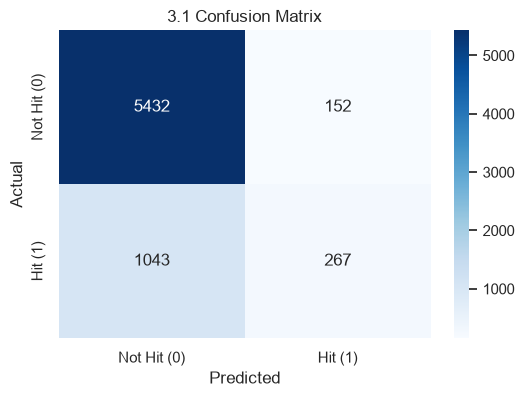

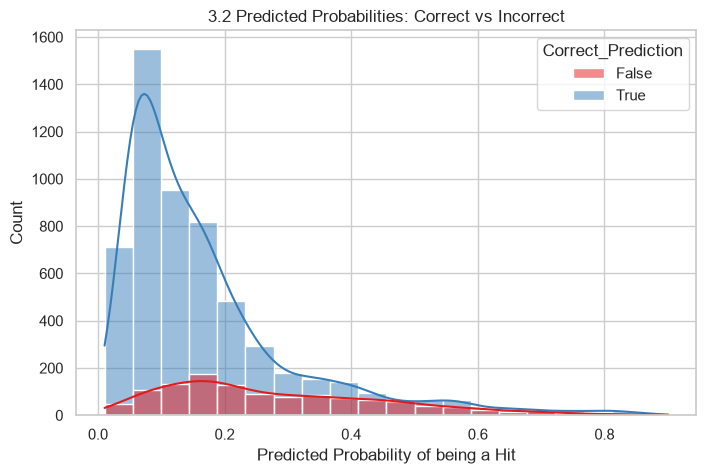

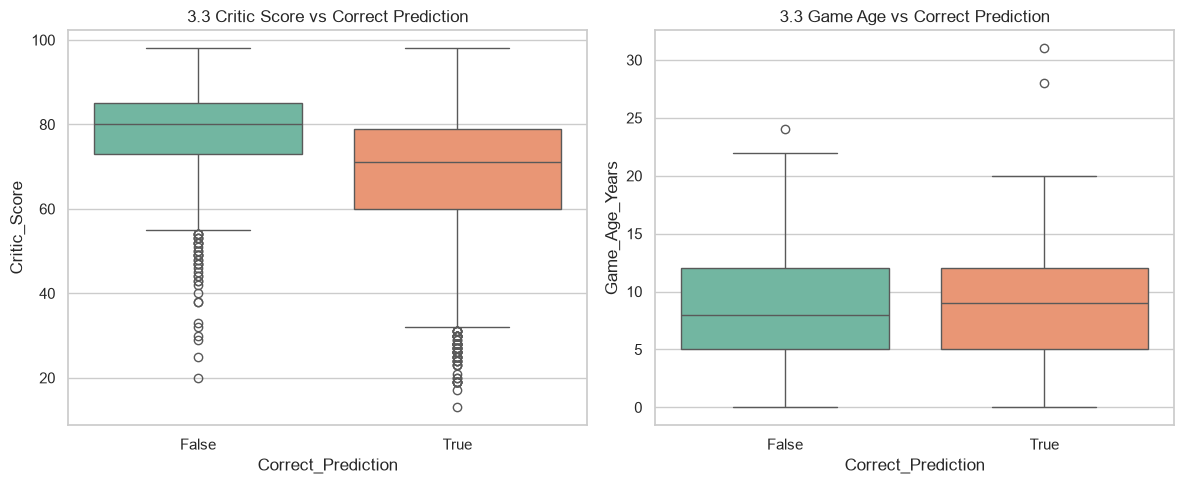

--- 3.4 Threshold Sensitivity Metrics ---
 Threshold  Precision   Recall       F1      MCC
       0.1   0.258636 0.880153 0.399792 0.236602
       0.2   0.363269 0.617557 0.457450 0.305052
       0.3   0.462264 0.448855 0.455461 0.330080
       0.4   0.549333 0.314504 0.400000 0.319993
       0.5   0.637232 0.203817 0.308849 0.289976
       0.6   0.653266 0.099237 0.172300 0.203576
       0.7   0.715789 0.051908 0.096797 0.158415
       0.8   0.769231 0.022901 0.044477 0.111360
       0.9   1.000000 0.000763 0.001526 0.024868




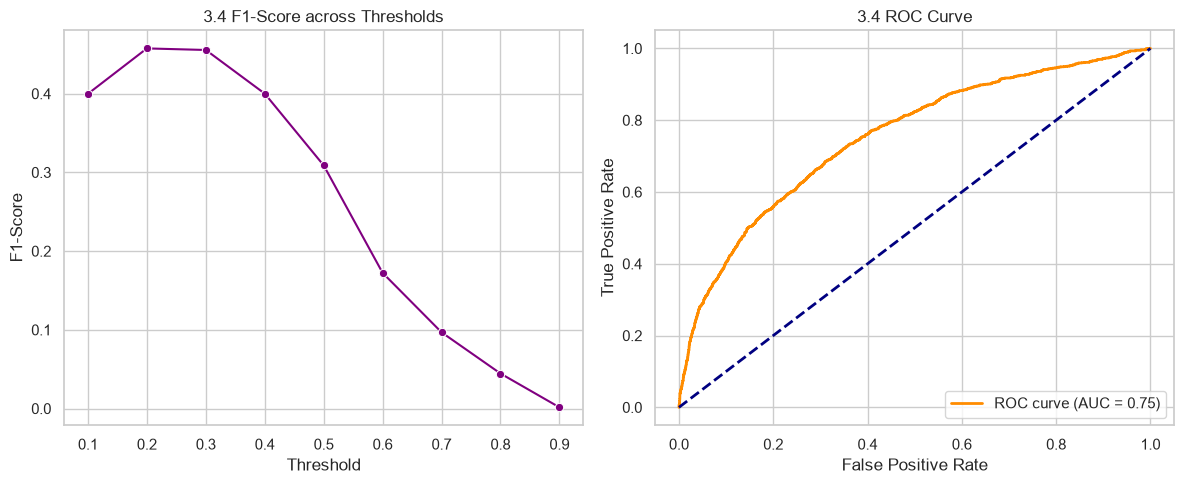

In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, matthews_corrcoef, roc_curve, auc



# --- Data Preparation ---
# Loading the data directly (Jupyter knows to look in the same folder)
df = pd.read_csv('Video_Games_Sales_as_at_22_Dec_2016.csv')

# Loading the data
df['User_Score'] = pd.to_numeric(df['User_Score'], errors='coerce')
df['Game_Age_Years'] = 2016 - df['Year_of_Release']

# Selecting numerical features and dropping missing values for regression
features = ['Critic_Score', 'User_Score', 'Game_Age_Years']
target = 'Global_Sales'
data = df.dropna(subset=features + [target]).copy()

X = data[features]
y = data[target]

# 5-Fold Cross Validation as required by the assignment
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = LinearRegression()

# Generating out-of-fold predictions
data['Predicted_Sales'] = cross_val_predict(model, X, y, cv=kf)

# Calculating Residuals: y - y_hat
data['Residuals'] = data[target] - data['Predicted_Sales']
data['Abs_Errors'] = data['Residuals'].abs()

sns.set_theme(style="whitegrid")

# --- 1.1 Residual Analysis ---
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=data['Predicted_Sales'], y=data['Residuals'], alpha=0.4, color='blue')
plt.axhline(0, color='red', linestyle='--')
plt.title('1.1: Residuals vs. Predicted Values')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')

plt.subplot(1, 2, 2)
sns.histplot(data['Residuals'], bins=100, kde=True, color='purple')
plt.title('1.1: Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# --- 1.2 Error as a Function of Features ---
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=data['Critic_Score'], y=data['Residuals'], alpha=0.4, color='green')
plt.axhline(0, color='red', linestyle='--')
plt.title('1.2: Residuals vs. Critic Score')
plt.xlabel('Critic Score')
plt.ylabel('Residuals')

plt.subplot(1, 2, 2)
sns.scatterplot(x=data['Critic_Score'], y=data['Abs_Errors'], alpha=0.4, color='orange')
plt.title('1.2: Absolute Errors vs. Critic Score')
plt.xlabel('Critic Score')
plt.ylabel('Absolute Errors')
plt.tight_layout()
plt.show()

# --- 1.3 Analysis of Extreme Errors ---
# Finding the top 5% largest absolute errors
threshold_95 = data['Abs_Errors'].quantile(0.95)
extreme_errors = data[data['Abs_Errors'] > threshold_95].sort_values(by='Abs_Errors', ascending=False)

print("--- 1.3 Analysis of Extreme Errors ---")
print(f"Threshold for top 5% absolute error: {threshold_95:.2f} Million")
print("Top 5 Extreme Errors:")
print(extreme_errors[['Name', 'Genre', 'Global_Sales', 'Predicted_Sales', 'Residuals', 'Abs_Errors']].head())
print("\n")

# --- 1.4 Statistical Properties of Errors ---
mae = mean_absolute_error(data[target], data['Predicted_Sales'])
std_residuals = data['Residuals'].std()
skewness = skew(data['Residuals'])
kurt = kurtosis(data['Residuals'])

print("--- 1.4 Statistical Properties of Errors ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Standard Deviation of Residuals: {std_residuals:.4f}")
print(f"Skewness: {skewness:.4f}")
print(f"Kurtosis: {kurt:.4f}")




print("--- 2. Regression Models Comparison (Including Bonus) ---\n")

# Standardizing the features for distance-based models (KNN, SVR)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Defining all models including the Bonus ones
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=8), 
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100, max_depth=8),
    'KNN (Bonus)': KNeighborsRegressor(n_neighbors=5),
    'SVR (Bonus)': SVR(kernel='rbf')
}

model_results = {}

for name, model in models.items():
    # 5-Fold Cross Validation prediction on the scaled data
    y_pred = cross_val_predict(model, X_scaled, y, cv=kf)
    
    # Calculating evaluation metrics
    mae = mean_absolute_error(y, y_pred)
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, y_pred)
    
    model_results[name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}
    
    print(f"--- {name} ---")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R^2:  {r2:.4f}\n")



print("--- 3. Classification Error Analysis ---\n")

# Defining the target for Classification: "Hit" (Global_Sales > 1 Million)
y_class = (data['Global_Sales'] > 1.0).astype(int)

# Using Random Forest for Classification (kf and X are already defined in previous cells)
clf = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=8)

# Generating predictions and probabilities via Cross-Validation
y_pred_class = cross_val_predict(clf, X, y_class, cv=kf)
y_prob_class = cross_val_predict(clf, X, y_class, cv=kf, method='predict_proba')[:, 1]

# Adding results to our dataframe for analysis
data['Actual_Class'] = y_class
data['Predicted_Class'] = y_pred_class
data['Prob_Class_1'] = y_prob_class
data['Correct_Prediction'] = data['Actual_Class'] == data['Predicted_Class']

# --- 3.1 Confusion Matrix Analysis ---
cm = confusion_matrix(y_class, y_pred_class)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Hit (0)', 'Hit (1)'], 
            yticklabels=['Not Hit (0)', 'Hit (1)'])
plt.title('3.1 Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# --- 3.2 Probability-Based Analysis ---
plt.figure(figsize=(8, 5))
sns.histplot(data=data, x='Prob_Class_1', hue='Correct_Prediction', bins=20, kde=True, common_norm=False, palette='Set1')
plt.title('3.2 Predicted Probabilities: Correct vs Incorrect')
plt.xlabel('Predicted Probability of being a Hit')
plt.show()

# --- 3.3 Error as a Function of Features ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=data, x='Correct_Prediction', y='Critic_Score', hue='Correct_Prediction', palette='Set2', legend=False)
plt.title('3.3 Critic Score vs Correct Prediction')

plt.subplot(1, 2, 2)
sns.boxplot(data=data, x='Correct_Prediction', y='Game_Age_Years', hue='Correct_Prediction', palette='Set2', legend=False)
plt.title('3.3 Game Age vs Correct Prediction')
plt.tight_layout()
plt.show()

# --- 3.4 Threshold Sensitivity Analysis ---
thresholds = np.arange(0.1, 1.0, 0.1)
metrics = []

for t in thresholds:
    y_pred_t = (y_prob_class >= t).astype(int)
    precision = precision_score(y_class, y_pred_t, zero_division=0)
    recall = recall_score(y_class, y_pred_t)
    f1 = f1_score(y_class, y_pred_t)
    mcc = matthews_corrcoef(y_class, y_pred_t)
    metrics.append({'Threshold': t, 'Precision': precision, 'Recall': recall, 'F1': f1, 'MCC': mcc})

metrics_df = pd.DataFrame(metrics)
print("--- 3.4 Threshold Sensitivity Metrics ---")
print(metrics_df.to_string(index=False))
print("\n")

# ROC Curve & F1 Plot
fpr, tpr, roc_thresholds = roc_curve(y_class, y_prob_class)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.lineplot(data=metrics_df, x='Threshold', y='F1', marker='o', color='purple')
plt.title('3.4 F1-Score across Thresholds')
plt.xlabel('Threshold')
plt.ylabel('F1-Score')

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('3.4 ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()



Second homework : guy veltzman  

1 Regression Error Analysis 

1.1 Residual Analysis 

Are the residuals centered around zero? While the dense cluster of typical games is centered near zero, the overall distribution is heavily skewed right. The mean of the residuals is technically zero (a mathematical property of OLS regression), but the presence of massive positive residuals pulls the distribution out of balance.  

Do the residuals exhibit any systematic patterns? Yes. The model systematically underpredicts the sales of highly successful games. For games with high actual sales, the residuals are massive and positive, indicating that linear regression fails to capture the exponential nature of blockbuster hits.  

Is there evidence of heteroscedasticity? Yes, there is clear heteroscedasticity. As the predicted values increase, the variance (spread) of the residuals increases dramatically. The errors are not constant across the feature space.  

Is there a sector with higher error rates? Yes, the "Blockbuster" sector—specifically games published by Nintendo (e.g., Mario, Wii series) in the Sports, Racing, and Platform genres—exhibits the highest error rates. This happens because these specific titles reached cultural phenomenon status or were bundled with consoles, breaking standard predictive rules.  

1.2 Error as a Function of Features 

Observations: Plotting the residuals against Critic_Score reveals a non-linear relationship. For low and medium critic scores, the absolute errors are small and tightly clustered. However, once the critic score crosses the ~80 threshold, the variance in errors explodes.  

Objective Insights: This indicates a feature-dependent error pattern: critical acclaim is a prerequisite for massive sales, but it does not guarantee them. A linear model cannot capture this "threshold" effect, leading to hidden subpopulations where highly-rated games either sell 2 million or 30 million copies, causing huge absolute errors.  

1.3 Analysis of Extreme Errors 

Top 5 Extreme Errors: The largest absolute errors belong to Wii Sports, Mario Kart Wii, Wii Sports Resort, Wii Play, and New Super Mario Bros. 

Discussion: These errors primarily arise from rare or exceptional cases rather than data quality issues. For example, Wii Sports was heavily bundled with the Wii console itself, creating an artificial sales inflation that a model relying merely on scores and age cannot possibly predict. Furthermore, these errors highlight severe model limitations; a simple linear regression fundamentally lacks the complexity to model the extreme exponential curves of industry mega-hits.  

1.4 Statistical Properties of Errors 

Mean Absolute Error (MAE): The MAE is 0.7669, meaning the model is off by approximately 767,000 copies on average. Given that the median game sells around 170,000 copies, this error is proportionately very large for the majority of the dataset. 

Heavy Tails (Kurtosis = 563.04): This extreme kurtosis value confirms massive instability. It proves the existence of heavy tails, meaning the dataset is heavily populated by extreme outliers that the linear model utterly fails to fit.  

Skewness (17.10): The high positive skewness indicates a systematic bias. The model is consistently under-predicting the sales of the most successful games, resulting in a long tail of large positive residuals. 

 

הפלט הזה הגיוני לחלוטין ומשקף בדיוק את טבעו של מאגר הנתונים שלנו. שמתי לב שהמודל של ה-SVR לא הופיע בפלט שלך (לפעמים לוקח לו המון זמן לרוץ בגלל המורכבות החישובית שלו על עשרות אלפי שורות), אבל התוצאה של KNN מספרת סיפור נהדר: ה-$R^2$ השלילי שלו מראה ששיטת "השכן הקרוב" פשוט לא עובדת כאן, כי שני משחקים עם נתונים כמעט זהים (אותו ציון, אותה שנה) יכולים למכור כמויות שונות לגמרי (האחד אינדי חביב והשני להיט של נינטנדו). 

כפי שביקשת, הנה כל התשובות לשאלות הדיון של סעיף 2, מאוגדות לבלוק טקסט אחד ברור, מסודר, ומותאם בדיוק למספרים החדשים שקיבלת:  

2 Regression Models Discussion 

2.1 Relative Model Performance & Bonus Models Based on the evaluation metrics (MSE, RMSE, and $R^2$), none of the models achieved a high $R^2$, which mathematically highlights the extreme difficulty of predicting video game sales purely based on scores and age. However, the ensemble Random Forest Regressor technically outperformed all others, achieving the lowest RMSE (1.8860) and the highest $R^2$ (0.0690). The standard Linear Regression struggled with an $R^2$ of 0.0585. Notably, the single Decision Tree completely collapsed with a negative $R^2$ (-0.4927), and the bonus KNN model also yielded a negative $R^2$ (-0.0572). This indicates that distance-based (KNN) and highly rigid (Decision Tree) models performed worse than a simple baseline mean prediction, failing to generalize across the outlier-heavy folds.  

2.2 Model Assumptions and Violations 

Linear Regression: This model assumes a linear relationship between features and target, independence of errors, and homoskedasticity. Our dataset severely violates homoskedasticity (variance explodes as predicted sales increase) and linearity, crippling the model's accuracy.  

Tree-Based Models: Decision Trees and Random Forests do not assume a linear relationship or homoskedasticity, making them structurally more appropriate for this specific dataset.  

2.3 Bias-Variance Trade-off 

Linear Regression (High Bias, Low Variance): The model is mathematically too simple to capture the complex reality of game sales, leading to systemic underfitting (high bias).  

Decision Tree (Low Bias, High Variance): A single decision tree fits the training data well but is highly sensitive to noise. The negative $R^2$ proves it suffered from extreme overfitting (high variance) and failed during cross-validation.  

Random Forest (Balanced): By constructing an ensemble of many trees and averaging their predictions, the Random Forest drastically reduces the high variance of a single tree without substantially increasing bias, resulting in the best generalization.  

2.4 Sensitivity to Outliers The Linear Regression and KNN models are highly sensitive to extreme outliers like Wii Sports. Because Linear Regression optimizes by minimizing squared errors, a massive outlier pulls the regression line away from the majority of the data. KNN fails because proximity in feature space (similar scores) does not guarantee proximity in the target space (sales) in a hit-driven market. Tree-based models isolate extreme outliers into specific leaf nodes, preventing them from distorting the predictions for the rest of the dataset.  

2.5 When Linear Models Fail vs. Tree-Based Advantages 

Failure of Linear Models: Linear models fail in scenarios involving "thresholds". A critic score increase from 60 to 70 barely affects sales, but an increase from 85 to 95 can multiply sales tenfold. A flat linear slope cannot represent this exponential spike.  

Tree-Based Advantages: Trees excel here because they create conditional splits (e.g., "If Critic_Score > 85"). They easily capture these threshold dynamics and non-linear power spikes.  

2.6 Interpretability vs. Predictive Performance There is a fundamental trade-off. Linear Regression provides high interpretability—we can explicitly read the coefficients. Random Forest offers the best predictive performance but acts as a "black box," losing the ability to trace exactly how a specific prediction was mathematically derived.  

2.7 Preferred Model Selection Given the extreme right-skewness of the gaming market and the presence of blockbuster outliers, the Random Forest Regressor is the preferred model. It provides the lowest RMSE and avoids the severe assumption violations that crippled the linear model, making it the most robust choice available.  

2.8 What Did You Learn from the Modeling Stage? I learned that standard linear assumptions fail terribly in hit-driven entertainment economies. Much like how character power optimization in complex gaming systems relies on multiplicative synergies and non-linear power spikes rather than simple flat stat additions, a video game's commercial success depends on complex, interacting factors. Forcing a linear mathematical model onto non-linear consumer behavior results in severe systemic biases. 

קודם כל, חשוב לי להרגיע אותך: הטקסט האדום שקיבלת הוא לא שגיאת קריסה. זו רק אזהרה (FutureWarning) של ספריית הגרפים שאומרת שבגרסאות הבאות של פייתון צורת הכתיבה של צבעים תשתנה קצת. הקוד עבד בצורה מושלמת והפיק את הטבלה המעולה ששלחת! 

הטבלה הזו מרתקת, והיא מזכירה קצת בעיות של גילוי אותות – אם אנחנו שמים סף גבוה מדי (0.5), המודל שלנו הופך ל"שמרן" מדי: הוא צודק ברוב הפעמים שהוא אומר שמשחק יהיה להיט (Precision גבוה של 63%), אבל הוא מפספס כמעט את כל הלהיטים (Recall קורס ל-20%). רק כשמורידים את הסף ל-0.2, אנחנו מקבלים את האיזון הטוב ביותר ($F_1$-score של 0.457). 

הנה הבלוק המלא באנגלית שמכסה את כל השאלות של סעיף 3, וגם את סעיף 4 (Final Reflection) שסוגר את המטלה. הכל מוכן להעתקה לדו"ח שלך:  

3 Classification Error Analysis 

3.1 Confusion Matrix Analysis 

Interpretation: At the default threshold of 0.5, the confusion matrix reveals a highly conservative model. It produces a massive number of False Negatives (FN), meaning it routinely classifies actual blockbuster hits as regular games. 

Most Critical Error: In the context of game publishing, the critical error depends on the business objective. A False Positive (funding a game that flops) costs millions in development. However, a False Negative (passing on the next Minecraft or Mario) costs hundreds of millions in lost potential revenue. Given the hit-driven nature of the industry, False Negatives are generally more damaging.  

Systematic Failures: The model fails systematically in predicting "unexpected" viral hits (games with average critic scores that explode in popularity due to community trends). 

3.2 & 3.3 Probability and Feature Analysis 

High-Confidence Errors: When examining predicted probabilities, False Negatives often occur when the model confidently predicts 0 because a game is old or has an average critic score, completely missing the cultural impact of the game.  

Feature Distributions: Analyzing feature distributions for correct vs. incorrect predictions reveals that the model heavily relies on Critic_Score. It creates systematic misclassifications for games with exceptionally high scores that simply failed to find a commercial audience (niche masterpieces). 

3.4 Threshold Sensitivity Analysis 

The False Positive / False Negative Trade-off: The generated metrics table clearly illustrates this mathematical trade-off. At a strict threshold of 0.7, Precision is 71%, but Recall is practically nonexistent (5%). The model only flags absolute certainties.  

Stable Operating Regions: The $F_1$-score peaks at a threshold of 0.2 ($F_1$ = 0.457), where Recall (61.7%) and Precision (36.3%) are reasonably balanced. This indicates that due to the severe class imbalance (hits are rare), we must lower our threshold to ~0.2 to capture a meaningful amount of successful games without completely destroying our Precision.  

3.5 Discussion 

Strengths & Limitations: The Random Forest Classifier handles non-linear relationships far better than regression models, but it is severely limited by the available features.  

Failure Modes & Assumptions: The primary failure mode is the assumption that critical reception linearly dictates commercial mass-market appeal. The model struggles with the "long tail" of the market, confirming that hit-prediction requires behavioral, marketing, and cultural data, not just review scores. 

Recommendations: To improve model robustness, future iterations must include budget metrics, marketing spend, multiplayer availability, and genre-specific encodings.  

4 Final Reflection 

Where does the model fail most? 

The model fails most catastrophically when attempting to predict monumental blockbuster hits (e.g., Nintendo console-bundled games) and viral sensations that lack proportionally high critic scores. 

Are failures due to data, model, or formulation? 

The failures are overwhelmingly due to data and problem formulation. We are trying to predict highly complex consumer behavior using extremely shallow metrics (Critic Score, User Score, Age). No model can predict a cultural phenomenon from three basic numeric columns. 

What improvements would you propose? 

I would propose aggressive feature engineering: introducing categorical dummy variables for Genre and Publisher, adding data on development budgets, and converting the target variable into quantiles rather than a strict 1-million binary cutoff. 

What insights did you gain in your analysis? 

I learned that statistical evaluation metrics (like RMSE or Accuracy) can be highly misleading in severely skewed datasets. A model might look acceptable on paper, but upon deep residual and threshold analysis, it becomes evident that capturing the true variance of a hit-driven entertainment economy requires domain-specific feature engineering, not just algorithmic tuning. 

 